# Portfolio Optimization on Nifty 50 Stocks — Modern Portfolio Theory (MPT)

**Objective:** Build an efficient frontier, identify the Minimum Variance Portfolio and the Maximum Sharpe Ratio (Tangency) Portfolio for a basket of 10 Nifty 50 stocks, backtest out-of-sample, and compare against the Nifty 50 index.

**Note:** This notebook needs internet access when you run it (to download price data via `yfinance`). Run cells in order, top to bottom.

## 0. Install & Import Libraries

In [1]:
# Run this once if libraries are not installed
!pip install yfinance numpy pandas matplotlib scipy seaborn


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.float_format', lambda x: f'{x:.4f}')


## 1. Define Stock Universe

We pick 10 liquid, large-cap Nifty 50 constituents across sectors (banking, IT, FMCG, energy, infra) to keep the portfolio diversified. Feel free to swap tickers — just keep the `.NS` suffix for NSE-listed stocks on Yahoo Finance.

In [3]:
tickers = [
    'RELIANCE.NS',   # Energy / Conglomerate
    'TCS.NS',        # IT
    'HDFCBANK.NS',   # Banking
    'INFY.NS',       # IT
    'ICICIBANK.NS',  # Banking
    'HINDUNILVR.NS', # FMCG
    'ITC.NS',        # FMCG
    'KOTAKBANK.NS',  # Banking
    'LT.NS',         # Infra / Engineering
    'SBIN.NS'        # Banking (PSU)
]

start_date = '2019-01-01'
end_date   = '2024-12-31'

risk_free_rate = 0.07  # approx annualized 91-day T-bill / repo-linked proxy; update as needed


## 2. Data Collection

Download adjusted close prices for all tickers, align dates, and check for missing values.

In [4]:
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)['Close']
raw_data = raw_data[tickers]  # keep column order consistent
print(raw_data.shape)
raw_data.head()


[*********************100%***********************]  10 of 10 completed

(1480, 10)


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,ITC.NS,KOTAKBANK.NS,LT.NS,SBIN.NS
Date,,,,,,,,,,
2019-01-01,496.1964,1552.4882,496.1858,541.7258,348.0230,1591.3146,196.5027,248.4864,1283.0063,271.5512
2019-01-02,489.7339,1569.2141,491.6585,544.9840,348.8363,1576.7363,195.0430,246.5290,1268.4135,266.3848
2019-01-03,483.6919,1550.1627,487.8010,545.0656,347.5446,1580.0935,193.8266,245.4659,1241.2745,263.8469
2019-01-04,486.3035,1531.3154,489.1060,538.4675,349.4103,1574.1741,195.2863,247.9896,1235.0906,269.7838
2019-01-07,489.0035,1548.4905,489.8451,547.1427,351.8023,1577.0455,195.7728,247.7213,1231.3087,268.5601


In [5]:
# Check for missing values
print("Missing values per stock:")
print(raw_data.isna().sum())

# Forward-fill small gaps (holidays / listing mismatches), then drop any remaining NaN rows
prices = raw_data.ffill().dropna()
print("\nFinal shape after cleaning:", prices.shape)
prices.tail()


Missing values per stock:
Ticker
RELIANCE.NS      0
TCS.NS           0
HDFCBANK.NS      0
INFY.NS          0
ICICIBANK.NS     0
HINDUNILVR.NS    0
ITC.NS           0
KOTAKBANK.NS     0
LT.NS            0
SBIN.NS          0
dtype: int64

Final shape after cleaning: (1480, 10)


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,ITC.NS,KOTAKBANK.NS,LT.NS,SBIN.NS
Date,,,,,,,,,,
2024-12-23,1211.8347,3872.7373,874.0342,1829.4014,1276.1122,2273.3831,420.9047,348.0671,3571.9727,790.7333
2024-12-24,1212.2808,3892.4817,872.6269,1814.9034,1276.5549,2270.1270,424.6322,348.8050,3571.2366,781.9703
2024-12-26,1206.1339,3882.7961,869.0599,1813.3348,1276.6534,2267.4050,423.3009,349.5528,3561.1797,782.3555
2024-12-27,1210.5955,3878.8381,872.6997,1822.2238,1286.6907,2275.6672,424.7654,350.9687,3540.1826,770.0297
2024-12-30,1200.3340,3873.2031,862.8237,1812.0039,1273.9965,2277.8542,423.3453,347.1398,3511.5811,759.1000


## 3. Exploratory Analysis — Normalized Price Trend

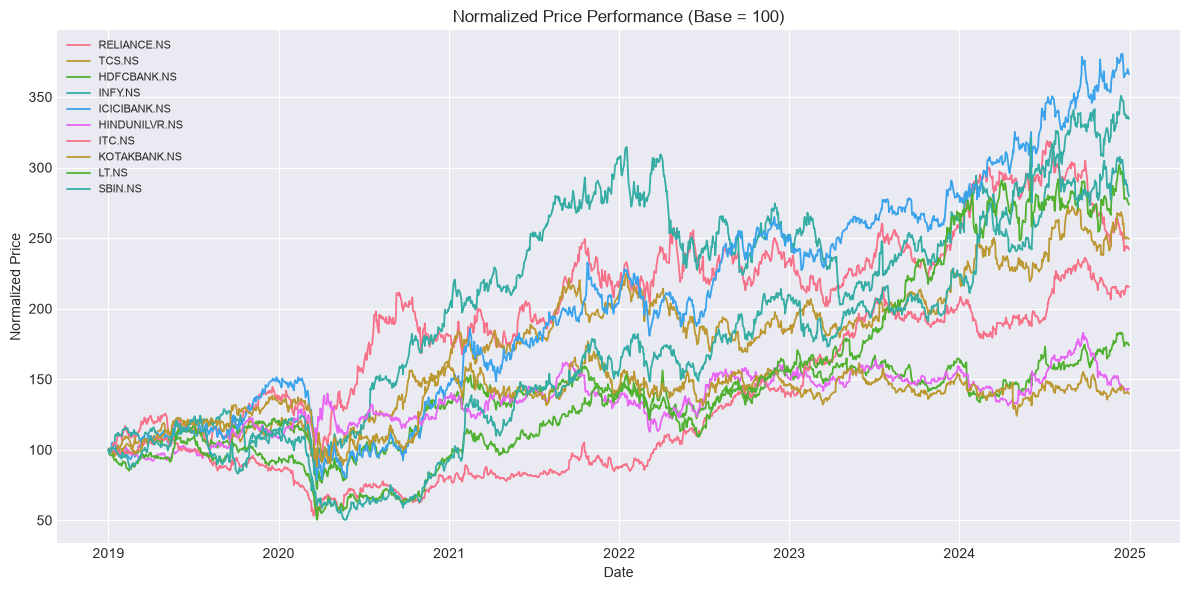

In [6]:
normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))
for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col, linewidth=1.3)
plt.title('Normalized Price Performance (Base = 100)')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


## 4. Compute Returns

We use **daily log returns**, then annualize the mean return (×252 trading days) and covariance matrix (×252).

In [7]:
log_returns = np.log(prices / prices.shift(1)).dropna()
log_returns.head()


Ticker,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,ITC.NS,KOTAKBANK.NS,LT.NS,SBIN.NS
Date,,,,,,,,,,
2019-01-02,-0.0131,0.0107,-0.0092,0.0060,0.0023,-0.0092,-0.0075,-0.0079,-0.0114,-0.0192
2019-01-03,-0.0124,-0.0122,-0.0079,0.0001,-0.0037,0.0021,-0.0063,-0.0043,-0.0216,-0.0096
2019-01-04,0.0054,-0.0122,0.0027,-0.0122,0.0054,-0.0038,0.0075,0.0102,-0.0050,0.0223
2019-01-07,0.0055,0.0112,0.0015,0.0160,0.0068,0.0018,0.0025,-0.0011,-0.0031,-0.0045
2019-01-08,-0.0001,-0.0023,-0.0084,-0.0025,0.0333,-0.0079,0.0092,-0.0143,-0.0012,0.0299


In [8]:
mean_returns_annual = log_returns.mean() * 252
cov_matrix_annual   = log_returns.cov() * 252

print("Annualized Expected Returns:")
print(mean_returns_annual.sort_values(ascending=False))


Annualized Expected Returns:
Ticker
ICICIBANK.NS    0.2211
INFY.NS         0.2057
SBIN.NS         0.1752
LT.NS           0.1716
TCS.NS          0.1558
RELIANCE.NS     0.1505
ITC.NS          0.1308
HDFCBANK.NS     0.0943
HINDUNILVR.NS   0.0611
KOTAKBANK.NS    0.0570
dtype: float64


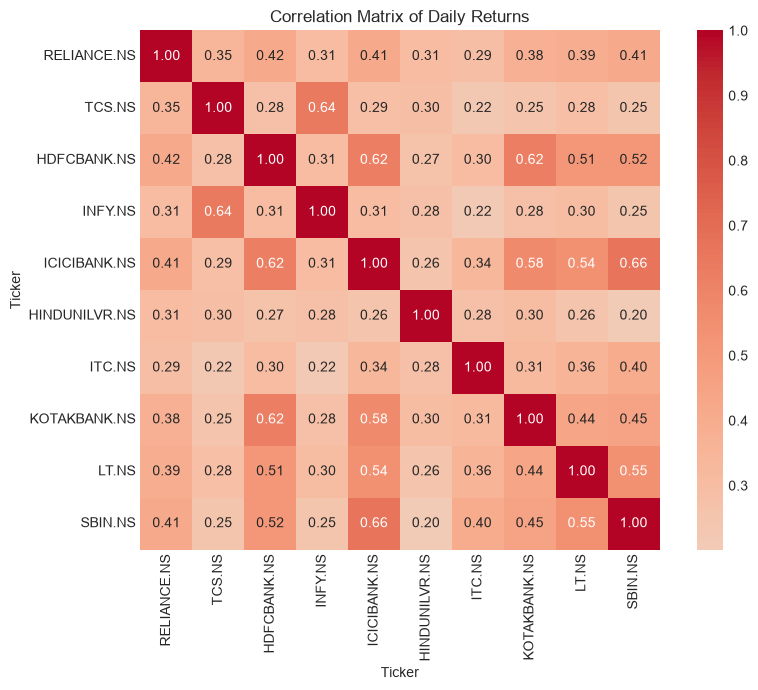

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(log_returns.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix of Daily Returns')
plt.tight_layout()
plt.show()


## 5. Monte Carlo Portfolio Simulation (Intuition Builder)

Before formal optimization, simulate thousands of random portfolios to visualize the risk-return cloud and see roughly where the efficient frontier sits.

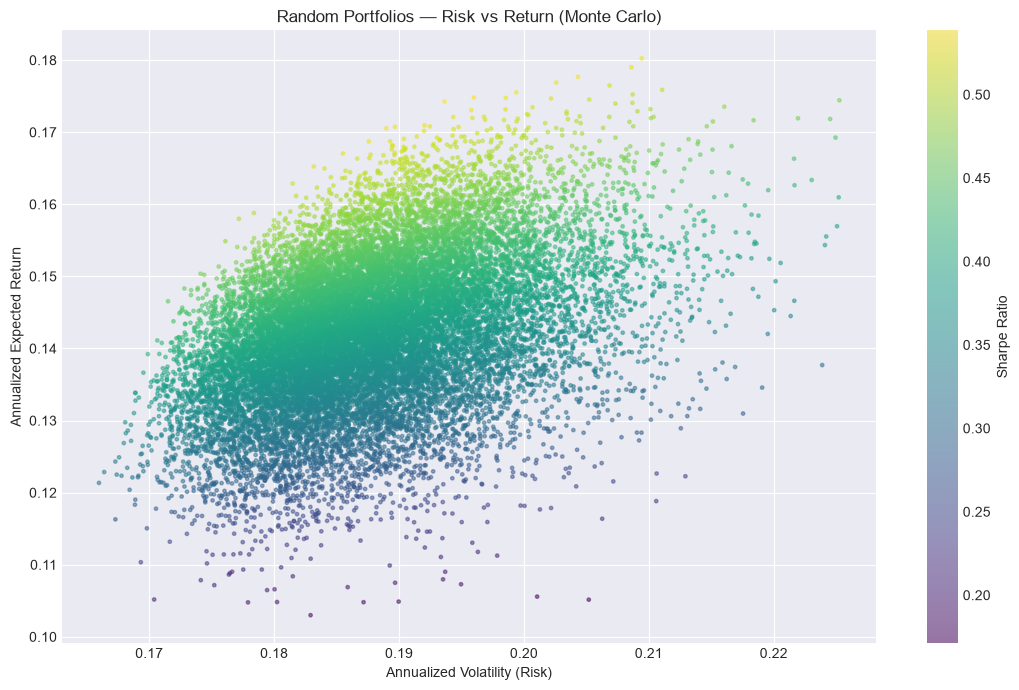

In [10]:
n_assets = len(tickers)
n_portfolios = 20000

results = np.zeros((3, n_portfolios))
weights_record = []

np.random.seed(42)
for i in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= np.sum(w)
    weights_record.append(w)

    port_return = np.dot(w, mean_returns_annual)
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix_annual, w)))
    sharpe = (port_return - risk_free_rate) / port_vol

    results[0, i] = port_vol
    results[1, i] = port_return
    results[2, i] = sharpe

plt.figure(figsize=(11, 7))
sc = plt.scatter(results[0], results[1], c=results[2], cmap='viridis', s=6, alpha=0.5)
plt.colorbar(sc, label='Sharpe Ratio')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.title('Random Portfolios — Risk vs Return (Monte Carlo)')
plt.tight_layout()
plt.show()


## 6. Efficient Frontier — Formal Optimization

Now solve the MPT optimization properly using `scipy.optimize`:

- **Minimize** portfolio variance for a series of target returns → traces the efficient frontier
- Constraints: weights sum to 1, no short-selling (`w >= 0`)

In [11]:
def portfolio_return(w, mean_returns):
    return np.dot(w, mean_returns)

def portfolio_volatility(w, cov_matrix):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

def neg_sharpe_ratio(w, mean_returns, cov_matrix, rf):
    ret = portfolio_return(w, mean_returns)
    vol = portfolio_volatility(w, cov_matrix)
    return -(ret - rf) / vol

def minimize_volatility(mean_returns, cov_matrix, target_return):
    n = len(mean_returns)
    args = (cov_matrix,)
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: portfolio_return(w, mean_returns) - target_return}
    )
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    result = minimize(portfolio_volatility, init_guess, args=args,
                       method='SLSQP', bounds=bounds, constraints=constraints)
    return result

target_returns = np.linspace(mean_returns_annual.min(), mean_returns_annual.max(), 100)
frontier_volatility = []
frontier_weights = []

for target in target_returns:
    res = minimize_volatility(mean_returns_annual, cov_matrix_annual, target)
    if res.success:
        frontier_volatility.append(res['fun'])
        frontier_weights.append(res['x'])
    else:
        frontier_volatility.append(np.nan)
        frontier_weights.append(None)

frontier_volatility = np.array(frontier_volatility)


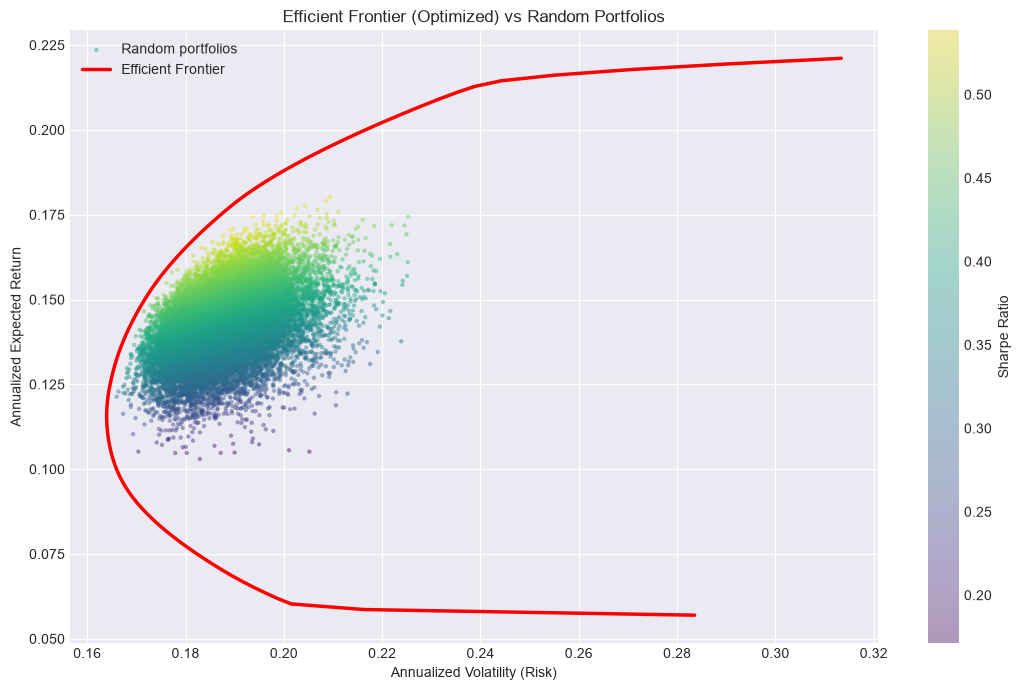

In [12]:
plt.figure(figsize=(11, 7))
plt.scatter(results[0], results[1], c=results[2], cmap='viridis', s=5, alpha=0.35, label='Random portfolios')
plt.plot(frontier_volatility, target_returns, 'r-', linewidth=2.5, label='Efficient Frontier')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.title('Efficient Frontier (Optimized) vs Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.show()


## 7. Minimum Variance Portfolio

In [13]:
def minimize_variance_only(mean_returns, cov_matrix):
    n = len(mean_returns)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    result = minimize(portfolio_volatility, init_guess, args=(cov_matrix,),
                       method='SLSQP', bounds=bounds, constraints=constraints)
    return result

min_var_result = minimize_variance_only(mean_returns_annual, cov_matrix_annual)
min_var_weights = min_var_result['x']

min_var_df = pd.DataFrame({'Ticker': tickers, 'Weight': min_var_weights}).sort_values('Weight', ascending=False)
min_var_df['Weight'] = min_var_df['Weight'].apply(lambda x: f'{x:.2%}')

print(f"Min-Variance Portfolio | Expected Return: {portfolio_return(min_var_weights, mean_returns_annual):.2%} | "
      f"Volatility: {portfolio_volatility(min_var_weights, cov_matrix_annual):.2%}")
min_var_df


Min-Variance Portfolio | Expected Return: 11.55% | Volatility: 16.40%


,Ticker,Weight
5,HINDUNILVR.NS,27.79%
1,TCS.NS,21.67%
6,ITC.NS,20.70%
2,HDFCBANK.NS,11.90%
8,LT.NS,5.48%
7,KOTAKBANK.NS,4.29%
3,INFY.NS,4.21%
0,RELIANCE.NS,3.97%
9,SBIN.NS,0.00%
4,ICICIBANK.NS,0.00%


## 8. Maximum Sharpe Ratio (Tangency) Portfolio

In [14]:
def maximize_sharpe(mean_returns, cov_matrix, rf):
    n = len(mean_returns)
    args = (mean_returns, cov_matrix, rf)
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    result = minimize(neg_sharpe_ratio, init_guess, args=args,
                       method='SLSQP', bounds=bounds, constraints=constraints)
    return result

max_sharpe_result = maximize_sharpe(mean_returns_annual, cov_matrix_annual, risk_free_rate)
max_sharpe_weights = max_sharpe_result['x']

max_sharpe_df = pd.DataFrame({'Ticker': tickers, 'Weight': max_sharpe_weights}).sort_values('Weight', ascending=False)
max_sharpe_df['Weight'] = max_sharpe_df['Weight'].apply(lambda x: f'{x:.2%}')

ms_return = portfolio_return(max_sharpe_weights, mean_returns_annual)
ms_vol = portfolio_volatility(max_sharpe_weights, cov_matrix_annual)
ms_sharpe = (ms_return - risk_free_rate) / ms_vol

print(f"Max-Sharpe Portfolio | Expected Return: {ms_return:.2%} | Volatility: {ms_vol:.2%} | Sharpe: {ms_sharpe:.2f}")
max_sharpe_df


Max-Sharpe Portfolio | Expected Return: 20.50% | Volatility: 22.47% | Sharpe: 0.60


,Ticker,Weight
3,INFY.NS,47.19%
4,ICICIBANK.NS,38.94%
8,LT.NS,8.29%
6,ITC.NS,4.20%
1,TCS.NS,1.39%
2,HDFCBANK.NS,0.00%
9,SBIN.NS,0.00%
0,RELIANCE.NS,0.00%
5,HINDUNILVR.NS,0.00%
7,KOTAKBANK.NS,0.00%


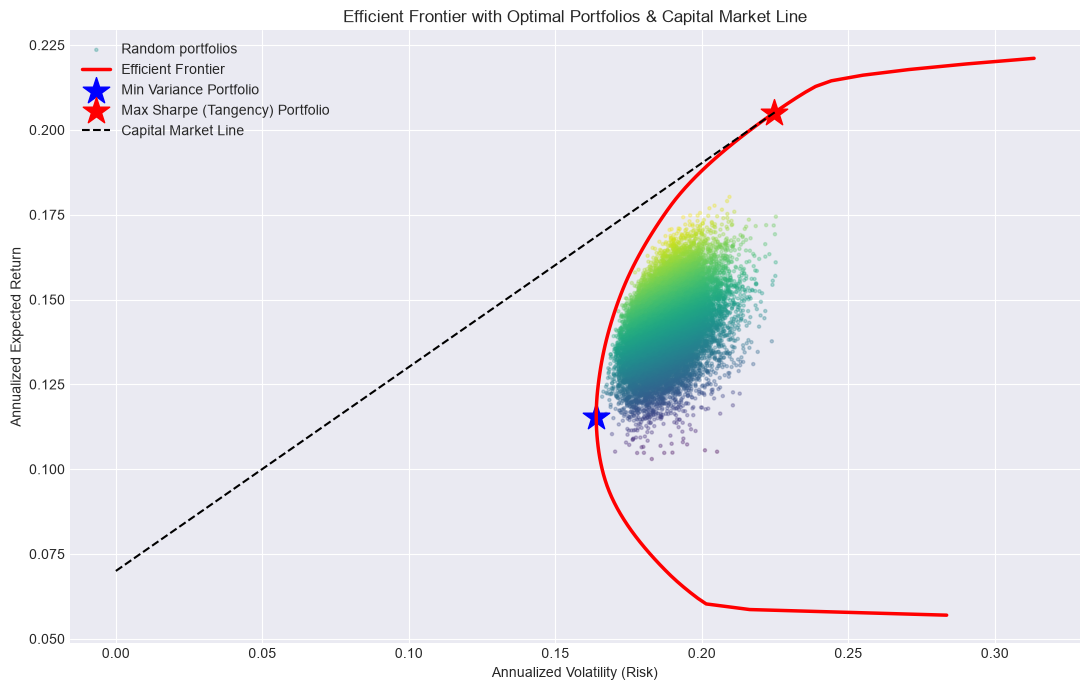

In [15]:
# Plot frontier with Capital Market Line (CML), Min-Var and Max-Sharpe points
plt.figure(figsize=(11, 7))
plt.scatter(results[0], results[1], c=results[2], cmap='viridis', s=5, alpha=0.3, label='Random portfolios')
plt.plot(frontier_volatility, target_returns, 'r-', linewidth=2.5, label='Efficient Frontier')

plt.scatter(portfolio_volatility(min_var_weights, cov_matrix_annual),
            portfolio_return(min_var_weights, mean_returns_annual),
            marker='*', color='blue', s=400, label='Min Variance Portfolio')

plt.scatter(ms_vol, ms_return, marker='*', color='red', s=400, label='Max Sharpe (Tangency) Portfolio')

# Capital Market Line: from risk-free rate through tangency portfolio
cml_x = np.linspace(0, max(results[0]), 50)
cml_y = risk_free_rate + ms_sharpe * cml_x
plt.plot(cml_x, cml_y, 'k--', linewidth=1.5, label='Capital Market Line')

plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.title('Efficient Frontier with Optimal Portfolios & Capital Market Line')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Out-of-Sample Backtest

Split data into an **estimation window** (used to compute μ, Σ and optimize weights) and a **test window** (used only to evaluate realized performance). This avoids look-ahead bias.

In [16]:
split_date = '2023-06-30'

train_returns = log_returns.loc[:split_date]
test_returns  = log_returns.loc[split_date:]

train_mean = train_returns.mean() * 252
train_cov  = train_returns.cov() * 252

# Re-optimize weights using ONLY training data
min_var_train = minimize_variance_only(train_mean, train_cov)['x']
max_sharpe_train = maximize_sharpe(train_mean, train_cov, risk_free_rate)['x']
equal_weights = np.array(n_assets * [1. / n_assets])

print("Train window:", train_returns.index.min().date(), "to", train_returns.index.max().date())
print("Test window: ", test_returns.index.min().date(), "to", test_returns.index.max().date())


Train window: 2019-01-02 to 2023-06-30
Test window:  2023-06-30 to 2024-12-30


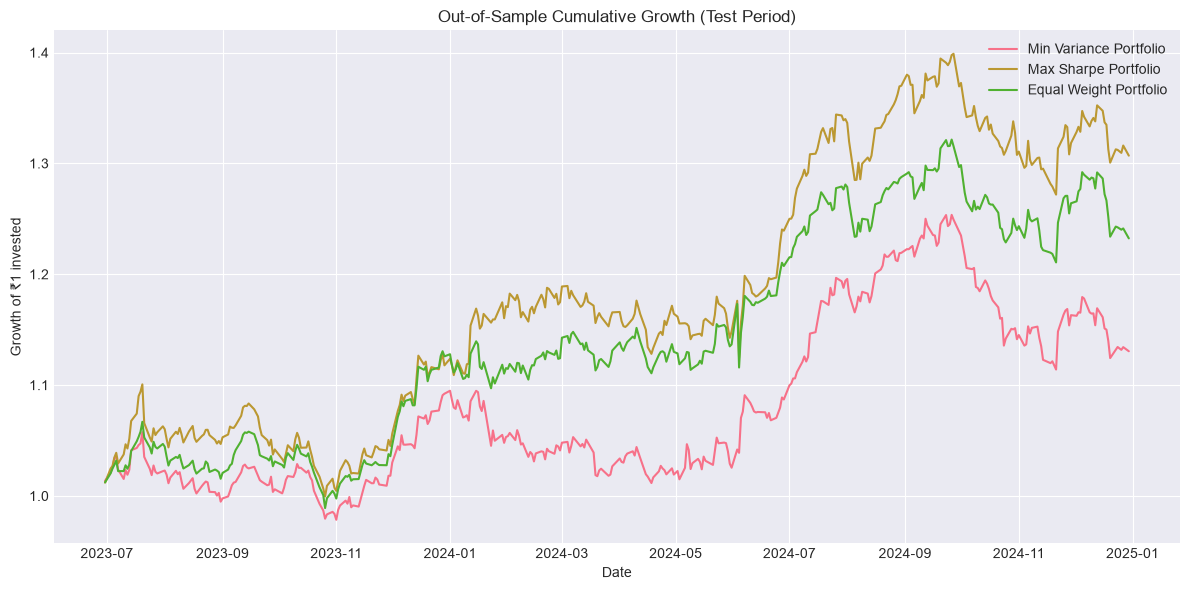

In [27]:
def portfolio_cumulative_returns(weights, daily_simple_returns):
    port_daily_simple_ret = daily_simple_returns.values @ weights
    cum_ret = np.cumprod(1 + port_daily_simple_ret)
    return pd.Series(cum_ret, index=daily_simple_returns.index)

simple_returns = prices.pct_change().dropna()
test_simple_returns = simple_returns.loc[split_date:]

cum_min_var   = portfolio_cumulative_returns(min_var_train, test_simple_returns)
cum_max_sharpe = portfolio_cumulative_returns(max_sharpe_train, test_simple_returns)
cum_equal      = portfolio_cumulative_returns(equal_weights, test_simple_returns)

plt.figure(figsize=(12, 6))
plt.plot(cum_min_var, label='Min Variance Portfolio')
plt.plot(cum_max_sharpe, label='Max Sharpe Portfolio')
plt.plot(cum_equal, label='Equal Weight Portfolio')
plt.title('Out-of-Sample Cumulative Growth (Test Period)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 invested')
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
def annualized_stats(cum_series, rf):
    daily_ret = cum_series.pct_change().dropna()
    ann_return = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol
    max_dd = ((cum_series / cum_series.cummax()) - 1).min()
    return ann_return, ann_vol, sharpe, max_dd

summary_rows = []
for name, series in [('Min Variance', cum_min_var), ('Max Sharpe', cum_max_sharpe), ('Equal Weight', cum_equal)]:
    ar, av, sr, mdd = annualized_stats(series, risk_free_rate)
    summary_rows.append([name, ar, av, sr, mdd])

summary_df = pd.DataFrame(summary_rows, columns=['Portfolio', 'Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown'])
summary_df['Ann. Return'] = summary_df['Ann. Return'].apply(lambda x: f'{x:.2%}')
summary_df['Ann. Volatility'] = summary_df['Ann. Volatility'].apply(lambda x: f'{x:.2%}')
summary_df['Max Drawdown'] = summary_df['Max Drawdown'].apply(lambda x: f'{x:.2%}')
summary_df


,Portfolio,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
0,Min Variance,8.20%,12.03%,0.0994,-11.13%
1,Max Sharpe,18.46%,13.73%,0.8346,-9.19%
2,Equal Weight,14.25%,12.47%,0.5819,-8.39%


## 10. Benchmark Against Nifty 50 Index

[*********************100%***********************]  1 of 1 completed


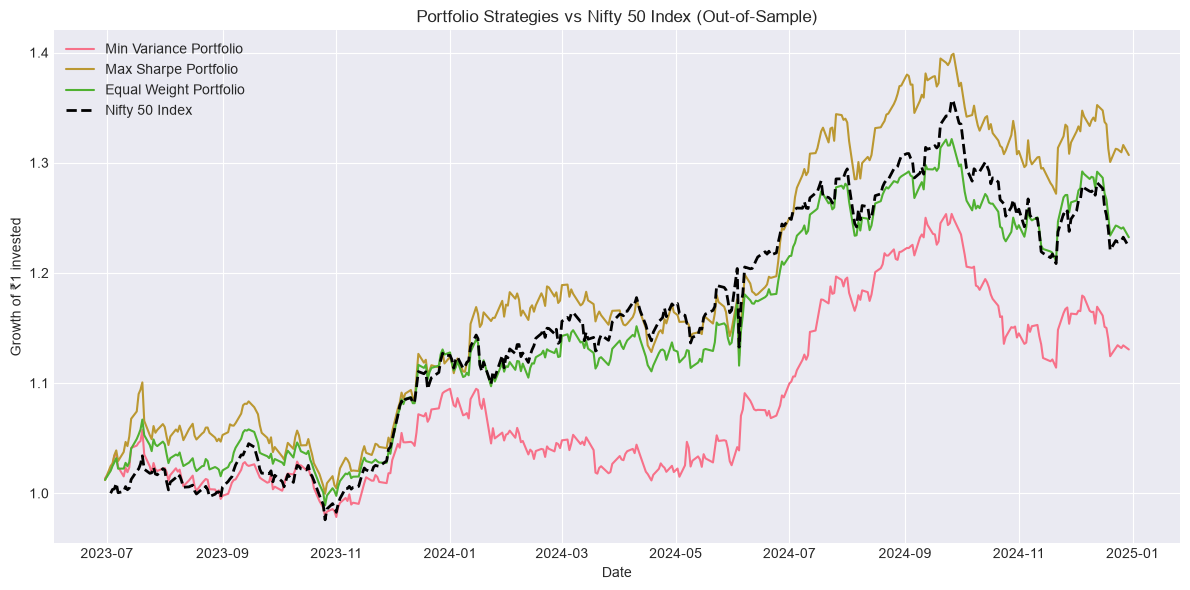

In [29]:
nifty = yf.download('^NSEI', start=split_date, end=end_date, auto_adjust=True)['Close'].squeeze()
nifty_log_ret = np.log(nifty / nifty.shift(1)).dropna()
nifty_cum = np.exp(nifty_log_ret.cumsum())
nifty_cum = nifty_cum / nifty_cum.iloc[0]  # normalize to start at 1, matching portfolio series

plt.figure(figsize=(12, 6))
plt.plot(cum_min_var, label='Min Variance Portfolio')
plt.plot(cum_max_sharpe, label='Max Sharpe Portfolio')
plt.plot(cum_equal, label='Equal Weight Portfolio')
plt.plot(nifty_cum, label='Nifty 50 Index', linewidth=2, color='black', linestyle='--')
plt.title('Portfolio Strategies vs Nifty 50 Index (Out-of-Sample)')
plt.xlabel('Date')
plt.ylabel('Growth of ₹1 invested')
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
nifty_ann_ret, nifty_ann_vol, nifty_sharpe, nifty_mdd = annualized_stats(nifty_cum, risk_free_rate)
print(f"Nifty 50 | Ann. Return: {nifty_ann_ret:.2%} | Ann. Vol: {nifty_ann_vol:.2%} | "
      f"Sharpe: {nifty_sharpe:.2f} | Max Drawdown: {nifty_mdd:.2%}")


Nifty 50 | Ann. Return: 14.68% | Ann. Vol: 12.75% | Sharpe: 0.60 | Max Drawdown: -10.93%


In [31]:
def annualized_stats(cum_series, rf):
    cum_series = cum_series.squeeze() if hasattr(cum_series, 'squeeze') else cum_series
    daily_ret = cum_series.pct_change().dropna()
    ann_return = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = (ann_return - rf) / ann_vol
    max_dd = ((cum_series / cum_series.cummax()) - 1).min()
    return ann_return, ann_vol, sharpe, max_dd

In [32]:
final_rows = []
for name, series in [('Min Variance', cum_min_var), ('Max Sharpe', cum_max_sharpe),
                      ('Equal Weight', cum_equal), ('Nifty 50', nifty_cum)]:
    ar, av, sr, mdd = annualized_stats(series, risk_free_rate)
    final_rows.append([name, ar, av, sr, mdd])

final_df = pd.DataFrame(final_rows, columns=['Portfolio', 'Ann. Return', 'Ann. Volatility', 'Sharpe Ratio', 'Max Drawdown'])
final_df_display = final_df.copy()
final_df_display['Ann. Return']     = final_df_display['Ann. Return'].apply(lambda x: f'{x:.2%}')
final_df_display['Ann. Volatility'] = final_df_display['Ann. Volatility'].apply(lambda x: f'{x:.2%}')
final_df_display['Sharpe Ratio']    = final_df_display['Sharpe Ratio'].apply(lambda x: f'{x:.2f}')
final_df_display['Max Drawdown']    = final_df_display['Max Drawdown'].apply(lambda x: f'{x:.2%}')
final_df_display

,Portfolio,Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
0,Min Variance,8.20%,12.03%,0.10,-11.13%
1,Max Sharpe,18.46%,13.73%,0.83,-9.19%
2,Equal Weight,14.25%,12.47%,0.58,-8.39%
3,Nifty 50,14.68%,12.75%,0.60,-10.93%


In [33]:
def historical_var_cvar(daily_returns, weights, confidence=0.95):
    port_ret = daily_returns.values @ weights
    var = -np.percentile(port_ret, (1 - confidence) * 100)
    cvar = -port_ret[port_ret <= -var].mean()
    return var, cvar

var_rows = []
for name, w in [('Min Variance', min_var_train), ('Max Sharpe', max_sharpe_train), ('Equal Weight', equal_weights)]:
    var95, cvar95 = historical_var_cvar(test_returns, w, 0.95)
    var99, cvar99 = historical_var_cvar(test_returns, w, 0.99)
    var_rows.append([name, var95, cvar95, var99, cvar99])

var_df = pd.DataFrame(var_rows, columns=['Portfolio', 'Daily VaR 95%', 'Daily CVaR 95%', 'Daily VaR 99%', 'Daily CVaR 99%'])
for c in var_df.columns[1:]:
    var_df[c] = var_df[c].apply(lambda x: f'{x:.2%}')
var_df

,Portfolio,Daily VaR 95%,Daily CVaR 95%,Daily VaR 99%,Daily CVaR 99%
0,Min Variance,1.10%,1.58%,1.78%,2.55%
1,Max Sharpe,1.16%,1.79%,1.97%,3.15%
2,Equal Weight,1.17%,1.69%,1.87%,2.94%


## 11. Conclusions & Known Limitations

Summarize your findings here after running the notebook, e.g.:
- Which portfolio had the best realized Sharpe ratio out-of-sample?
- Did the Max-Sharpe portfolio concentrate heavily in 1-2 stocks? (common MPT issue)
- How did all strategies compare to simply holding the Nifty 50 index?

**Known limitations of this approach (worth discussing in your report):**
1. **Estimation error** — mean returns are notoriously noisy; small changes in μ can swing optimal weights drastically.
2. **Non-normality** — stock returns exhibit fat tails and skew; MPT assumes a mean-variance (roughly normal) world.
3. **Static covariance** — correlations shift in crises (they tend to rise), reducing diversification exactly when you need it.
4. **No transaction costs / taxes** modeled in the backtest above.
5. **Concentration risk** — unconstrained Max-Sharpe optimization often produces highly concentrated portfolios; consider adding a max-weight-per-stock constraint (e.g., `bounds = (0, 0.3)`) as an extension.

### Suggested Extensions
- Add sector/weight caps as constraints
- Use Ledoit-Wolf shrinkage for the covariance matrix (`sklearn.covariance.LedoitWolf`)
- Try a rolling-window backtest (re-optimize every quarter) instead of a single train/test split
- Add a Black-Litterman layer to blend market equilibrium returns with your own views